# Exploratory Data Analysis
---
**Objectives:**
- Understand the structure and quality of the data
- Identify missing values, outliers, and data quality issues
- Explore feature distributions and their relationship with the target
- Document findings to inform preprocessing and feature engineering decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global constants ───
DATA_PATH    = '../data/raw/credit_risk_dataset.csv'
RANDOM_STATE = 42
TARGET_COL   = 'loan_status'

# ── Plot aesthetics ──
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.figsize'  : (10, 5),
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

# Consistent palette for binary target
PALETTE = {'0': '#4C72B0', '1': '#DD8452'}   # blue = no default, orange = default

print('Libraries loaded.')

Libraries loaded.


## Load & Inspect Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [4]:
# Identify column types for later use
NUMERICAL_COLS   = df.select_dtypes(include=['int64', 'float64']).columns.drop(TARGET_COL).tolist()
CATEGORICAL_COLS = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical  :', NUMERICAL_COLS)
print('Categorical:', CATEGORICAL_COLS)

Numerical  : ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**Observations:**
- Note `person_age` max and `person_emp_length` max — both look suspiciously high.
- `person_income` shows extreme right skew (large gap between mean and max).
- We'll investigate these further in the outlier section.

## Missing Value Analysis

                   count   pct
loan_int_rate       3116  9.56
person_emp_length    895  2.75


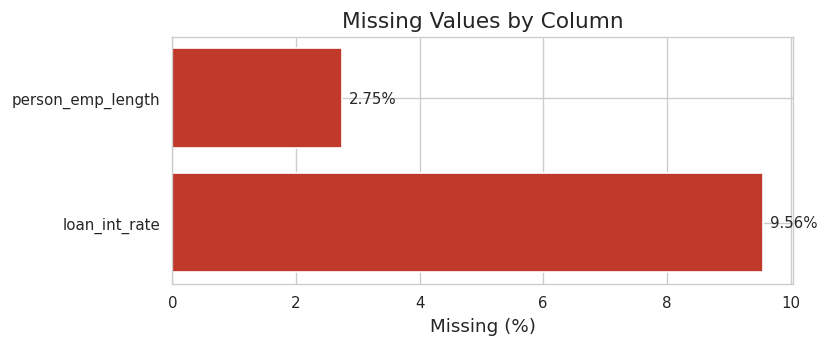

In [6]:
missing = (
    df.isnull().sum()
      .rename('count')
      .to_frame()
)
missing['pct'] = (missing['count'] / len(df) * 100).round(2)
missing = missing[missing['count'] > 0].sort_values('pct', ascending=False)
print(missing)

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing.index, missing['pct'], color='#c0392b', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing['pct']):
    ax.text(v + 0.1, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Findings:**
- `loan_int_rate` and `person_emp_length` have missing values.
- Missingness is non-trivial — we will handle this in `02_data_preprocessing.ipynb`.
- Imputation strategy: median for `person_emp_length`; group-wise median by `loan_grade` for `loan_int_rate` (since rate is grade-dependent).

## Target Distribution & Class Imbalance

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

Imbalance ratio (majority / minority): 3.58x


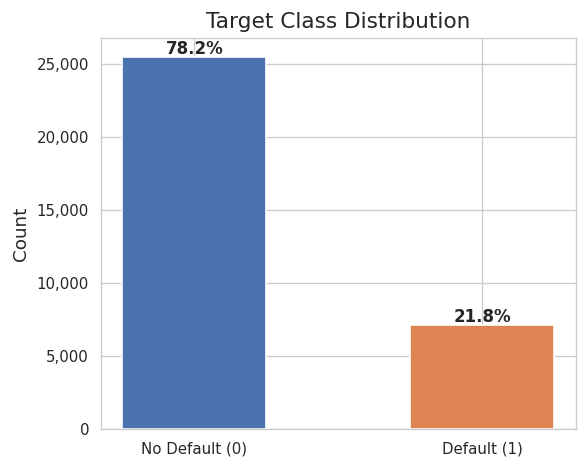

In [7]:
target_counts = df[TARGET_COL].value_counts()
target_pct    = df[TARGET_COL].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(2))
print(f'\nImbalance ratio (majority / minority): {target_counts[0] / target_counts[1]:.2f}x')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['No Default (0)', 'Default (1)'],
    target_counts.values,
    color=[PALETTE['0'], PALETTE['1']],
    edgecolor='white', width=0.5
)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Finding:** Dataset is moderately imbalanced (~78% non-default, ~22% default).  
**Implication:** Accuracy is a misleading metric here. We'll prioritize **ROC-AUC, F1, and Precision-Recall** during model evaluation. Class weighting or SMOTE may be considered in preprocessing.

## Univariate Analysis

### Numerical Features Distributions

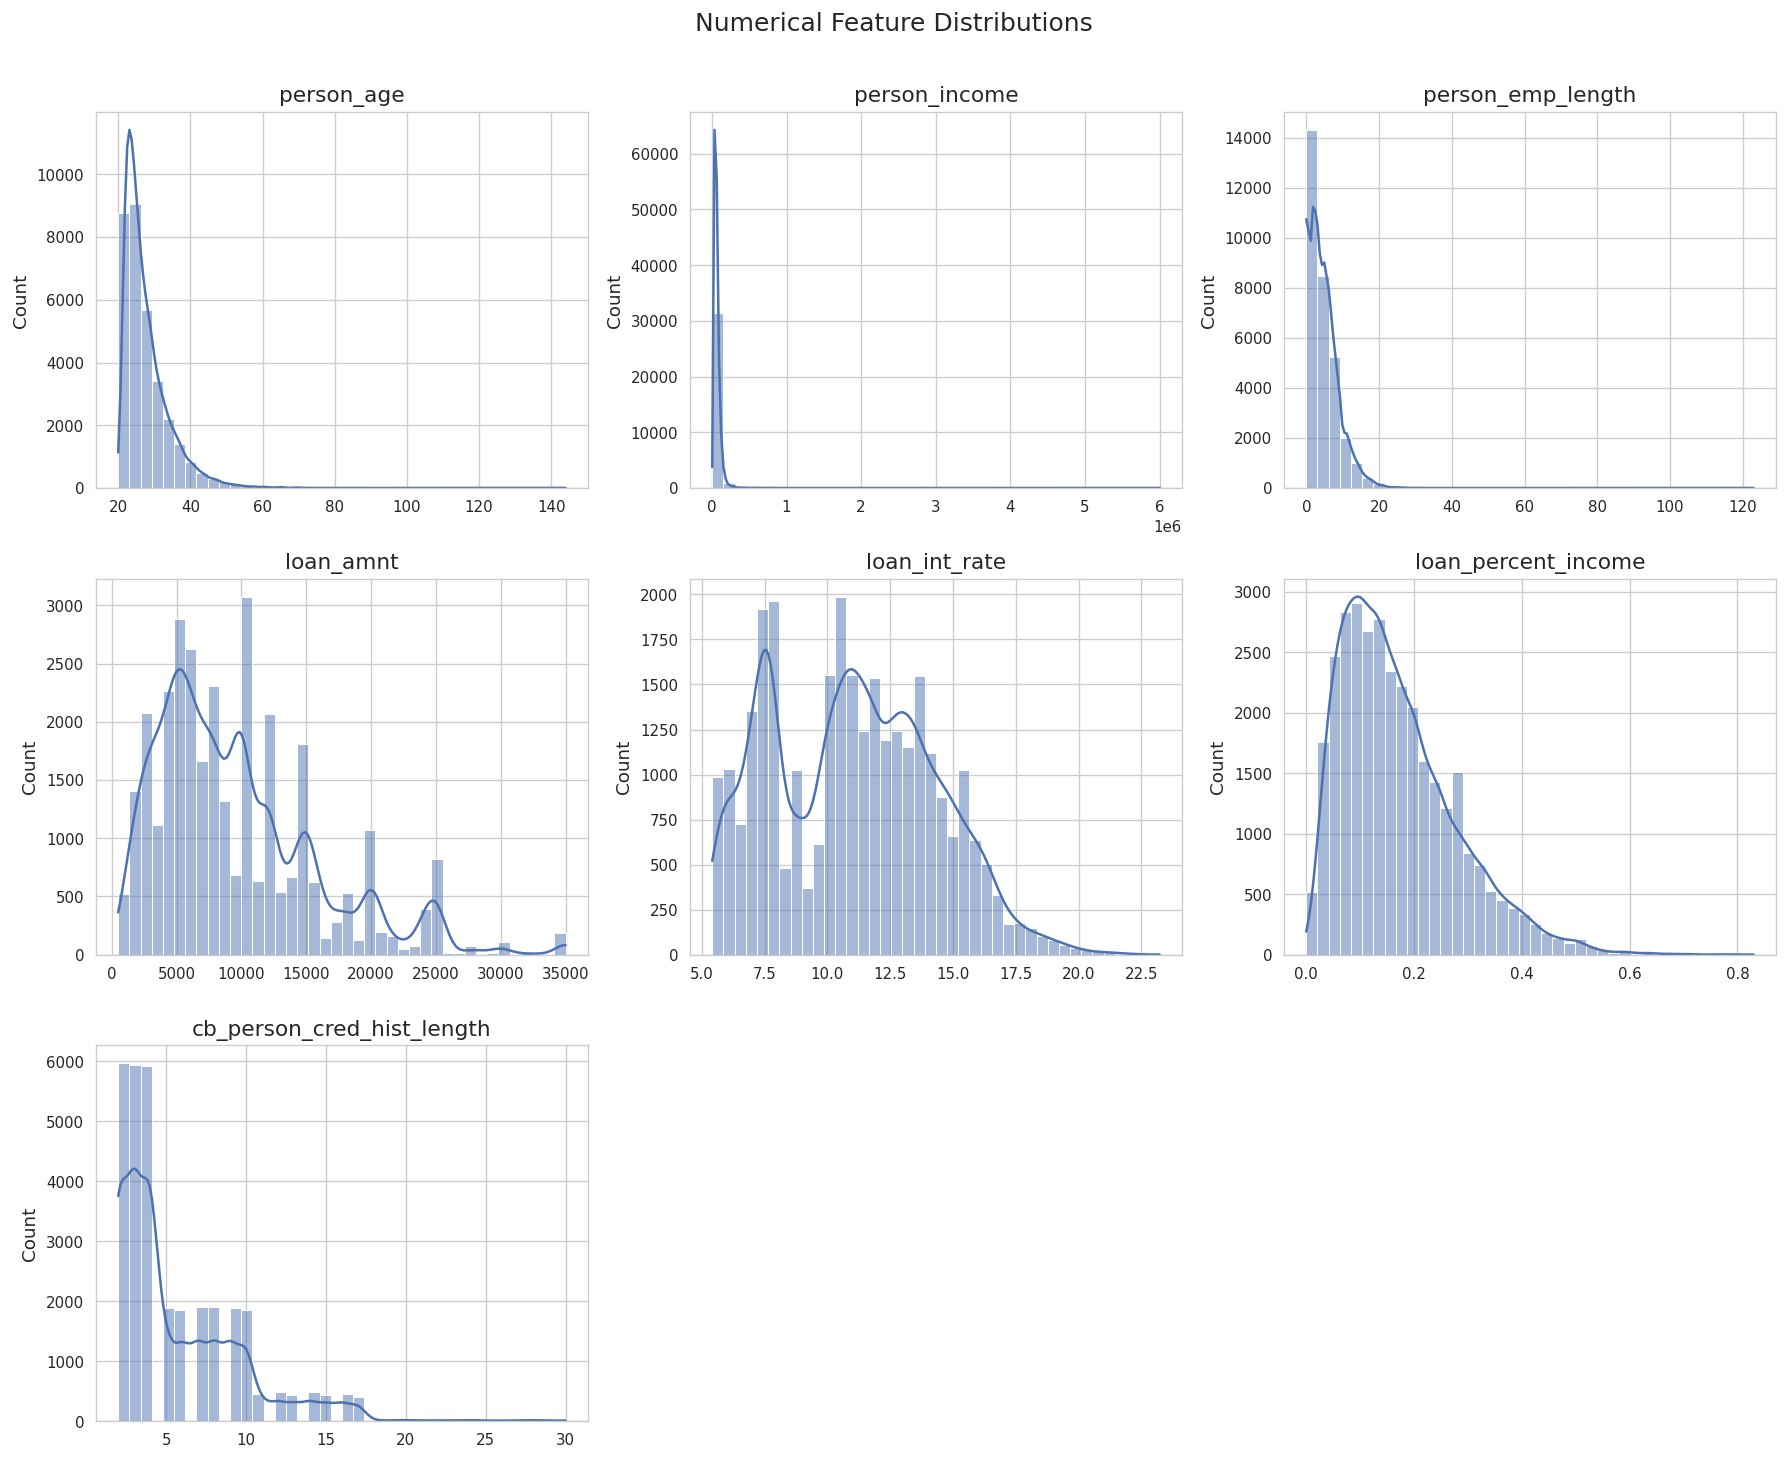

In [8]:
n_cols  = 3
n_rows  = int(np.ceil(len(NUMERICAL_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i],
                 color='#4C72B0', edgecolor='white', bins=40)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `person_income` and `loan_amnt` are heavily right-skewed, log transformation may help tree-based models less, but is useful for Logistic Regression.
- `person_age` and `person_emp_length` have suspicious extreme values visible in the tail, flagged for outlier treatment.
- `loan_int_rate` and `loan_percent_income` show relatively normal-ish distributions with some skew.

### Categorical Features: Value Counts

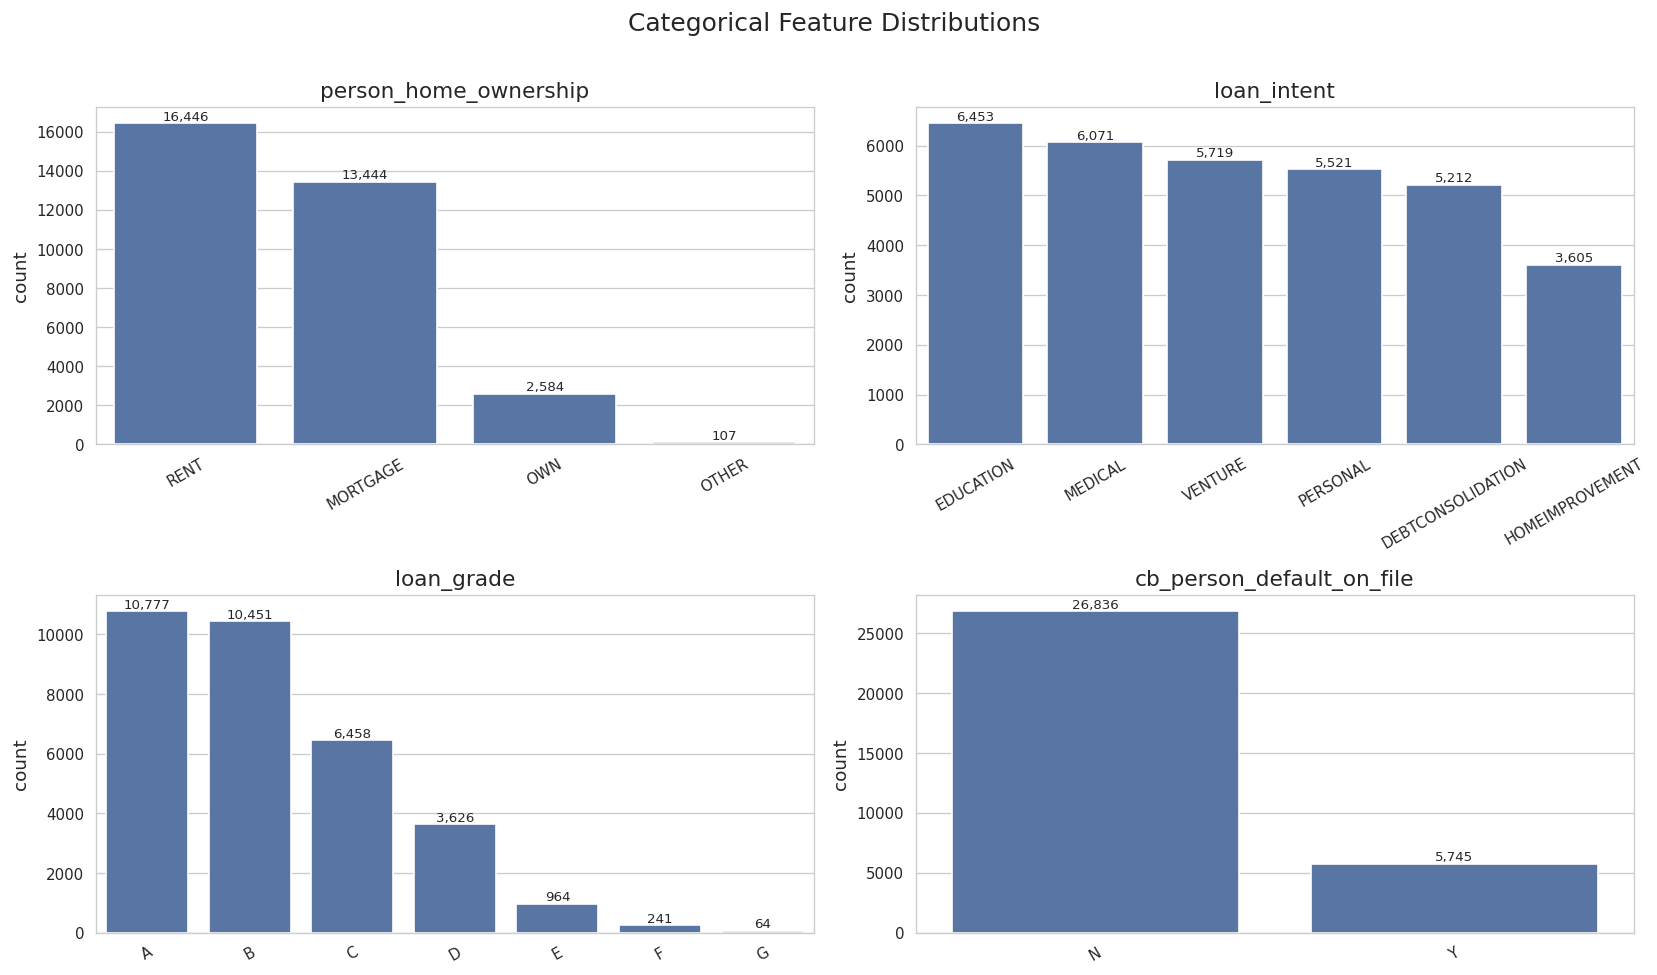

In [9]:
n_cols = 2
n_rows = int(np.ceil(len(CATEGORICAL_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, color='#4C72B0')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `loan_grade`: Most loans are Grade A-C. Grades F and G are rare, may need grouping.
- `person_home_ownership`: RENT and MORTGAGE dominate. OTHER is very sparse.
- `loan_intent`: Relatively balanced across categories.
- `cb_person_default_on_file`: Binary (Y/N), straightforward to encode.

## 5. Outlier Detection

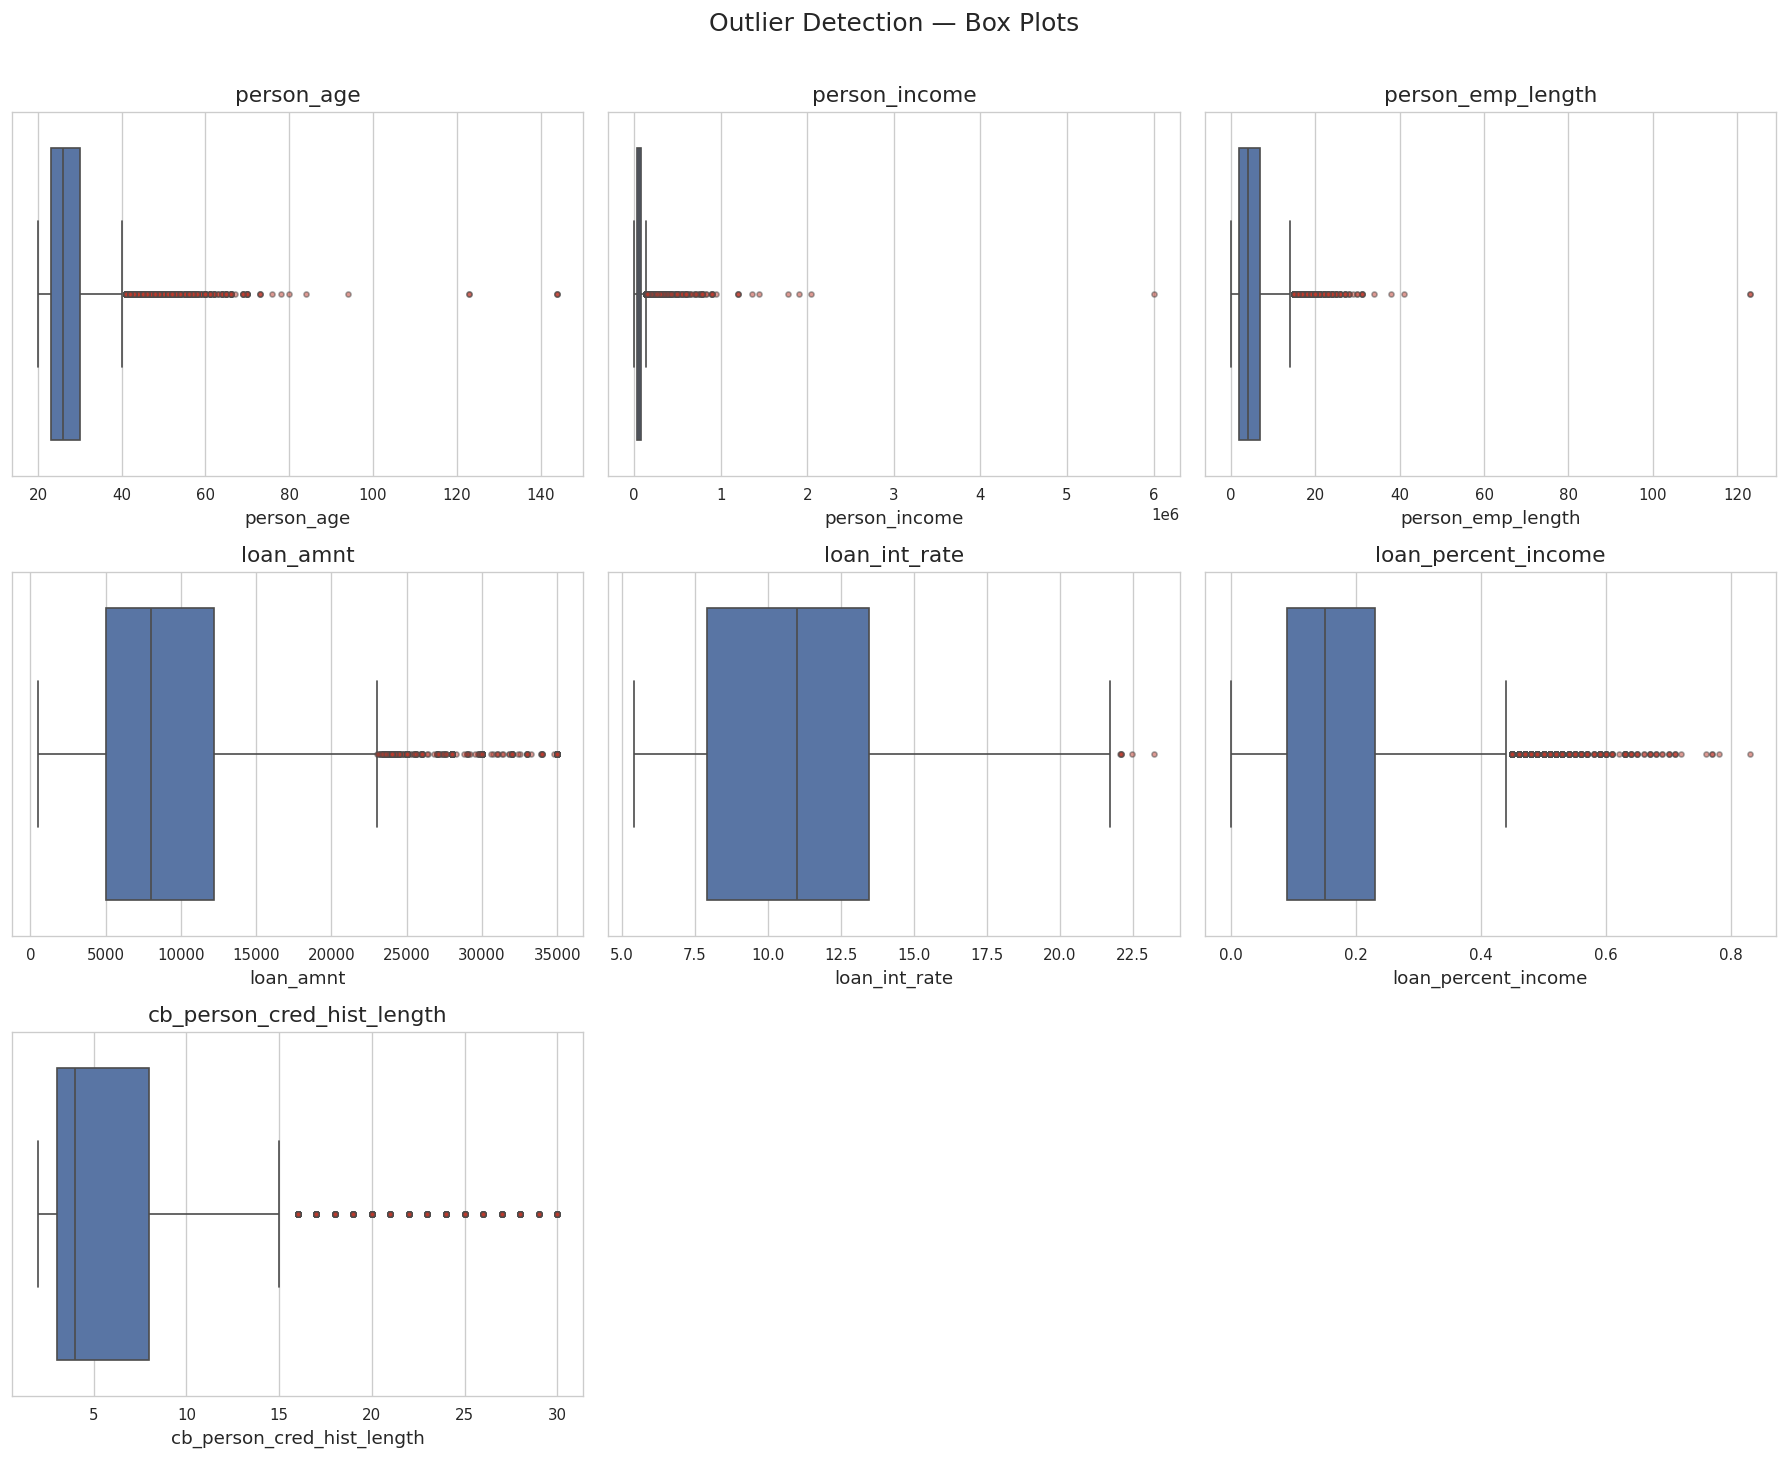

In [10]:
# Box plots for all numerical columns
n_cols_box = 3
n_rows_box = int(np.ceil(len(NUMERICAL_COLS) / n_cols_box))
fig, axes = plt.subplots(n_rows_box, n_cols_box, figsize=(15, n_rows_box * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='#4C72B0',
                flierprops=dict(marker='o', markerfacecolor='#c0392b',
                                markersize=3, alpha=0.5))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Outlier Detection — Box Plots', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# IQR-based outlier flagging
def count_outliers(series: pd.Series) -> dict:
    """Count IQR-based outliers and return summary stats.

    Args:
        series: Numerical pandas Series.

    Returns:
        Dict with Q1, Q3, IQR, lower/upper fences, and outlier count + pct.
    """
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_out  = ((series < lower) | (series > upper)).sum()
    return {
        'Q1': round(q1, 2), 'Q3': round(q3, 2),
        'Lower fence': round(lower, 2), 'Upper fence': round(upper, 2),
        'Outlier count': n_out,
        'Outlier %': round(n_out / len(series) * 100, 2)
    }

outlier_summary = pd.DataFrame(
    {col: count_outliers(df[col].dropna()) for col in NUMERICAL_COLS}
).T
outlier_summary.sort_values('Outlier %', ascending=False)

,Q1,Q3,Lower fence,Upper fence,Outlier count,Outlier %
loan_amnt,5000.00,12200.00,-5800.00,23000.00,1689.0,5.18
person_age,23.00,30.00,12.50,40.50,1494.0,4.59
person_income,38500.00,79200.00,-22550.00,140250.00,1484.0,4.55
cb_person_cred_hist_length,3.00,8.00,-4.50,15.50,1142.0,3.51
person_emp_length,2.00,7.00,-5.50,14.50,853.0,2.69
loan_percent_income,0.09,0.23,-0.12,0.44,651.0,2.00
loan_int_rate,7.90,13.47,-0.46,21.83,6.0,0.02


In [12]:
# Inspect extreme values specifically for known problem columns
print('person_age extremes:')
print(df['person_age'].describe())
print(f"\nRows with person_age > 100: {(df['person_age'] > 100).sum()}")

print('\nperson_emp_length extremes:')
print(df['person_emp_length'].describe())
print(f"Rows with person_emp_length > 60: {(df['person_emp_length'] > 60).sum()}")

person_age extremes:
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Rows with person_age > 100: 5

person_emp_length extremes:
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64
Rows with person_emp_length > 60: 2


**Findings:**
- `person_age` contains values > 100 -> biologically implausible, likely data entry errors.
- `person_emp_length` contains values > 60 -> cannot exceed working life, clearly erroneous.
- `person_income` has extreme high values but could be legitimate (high earners).

**Decision:** Drop rows where `person_age > 100` or `person_emp_length > 60` in preprocessing. These are not outliers to cap -> they are data errors to remove.

## 6. Bivariate Analysis — Features vs Target

### 6a. Numerical Features vs loan_status

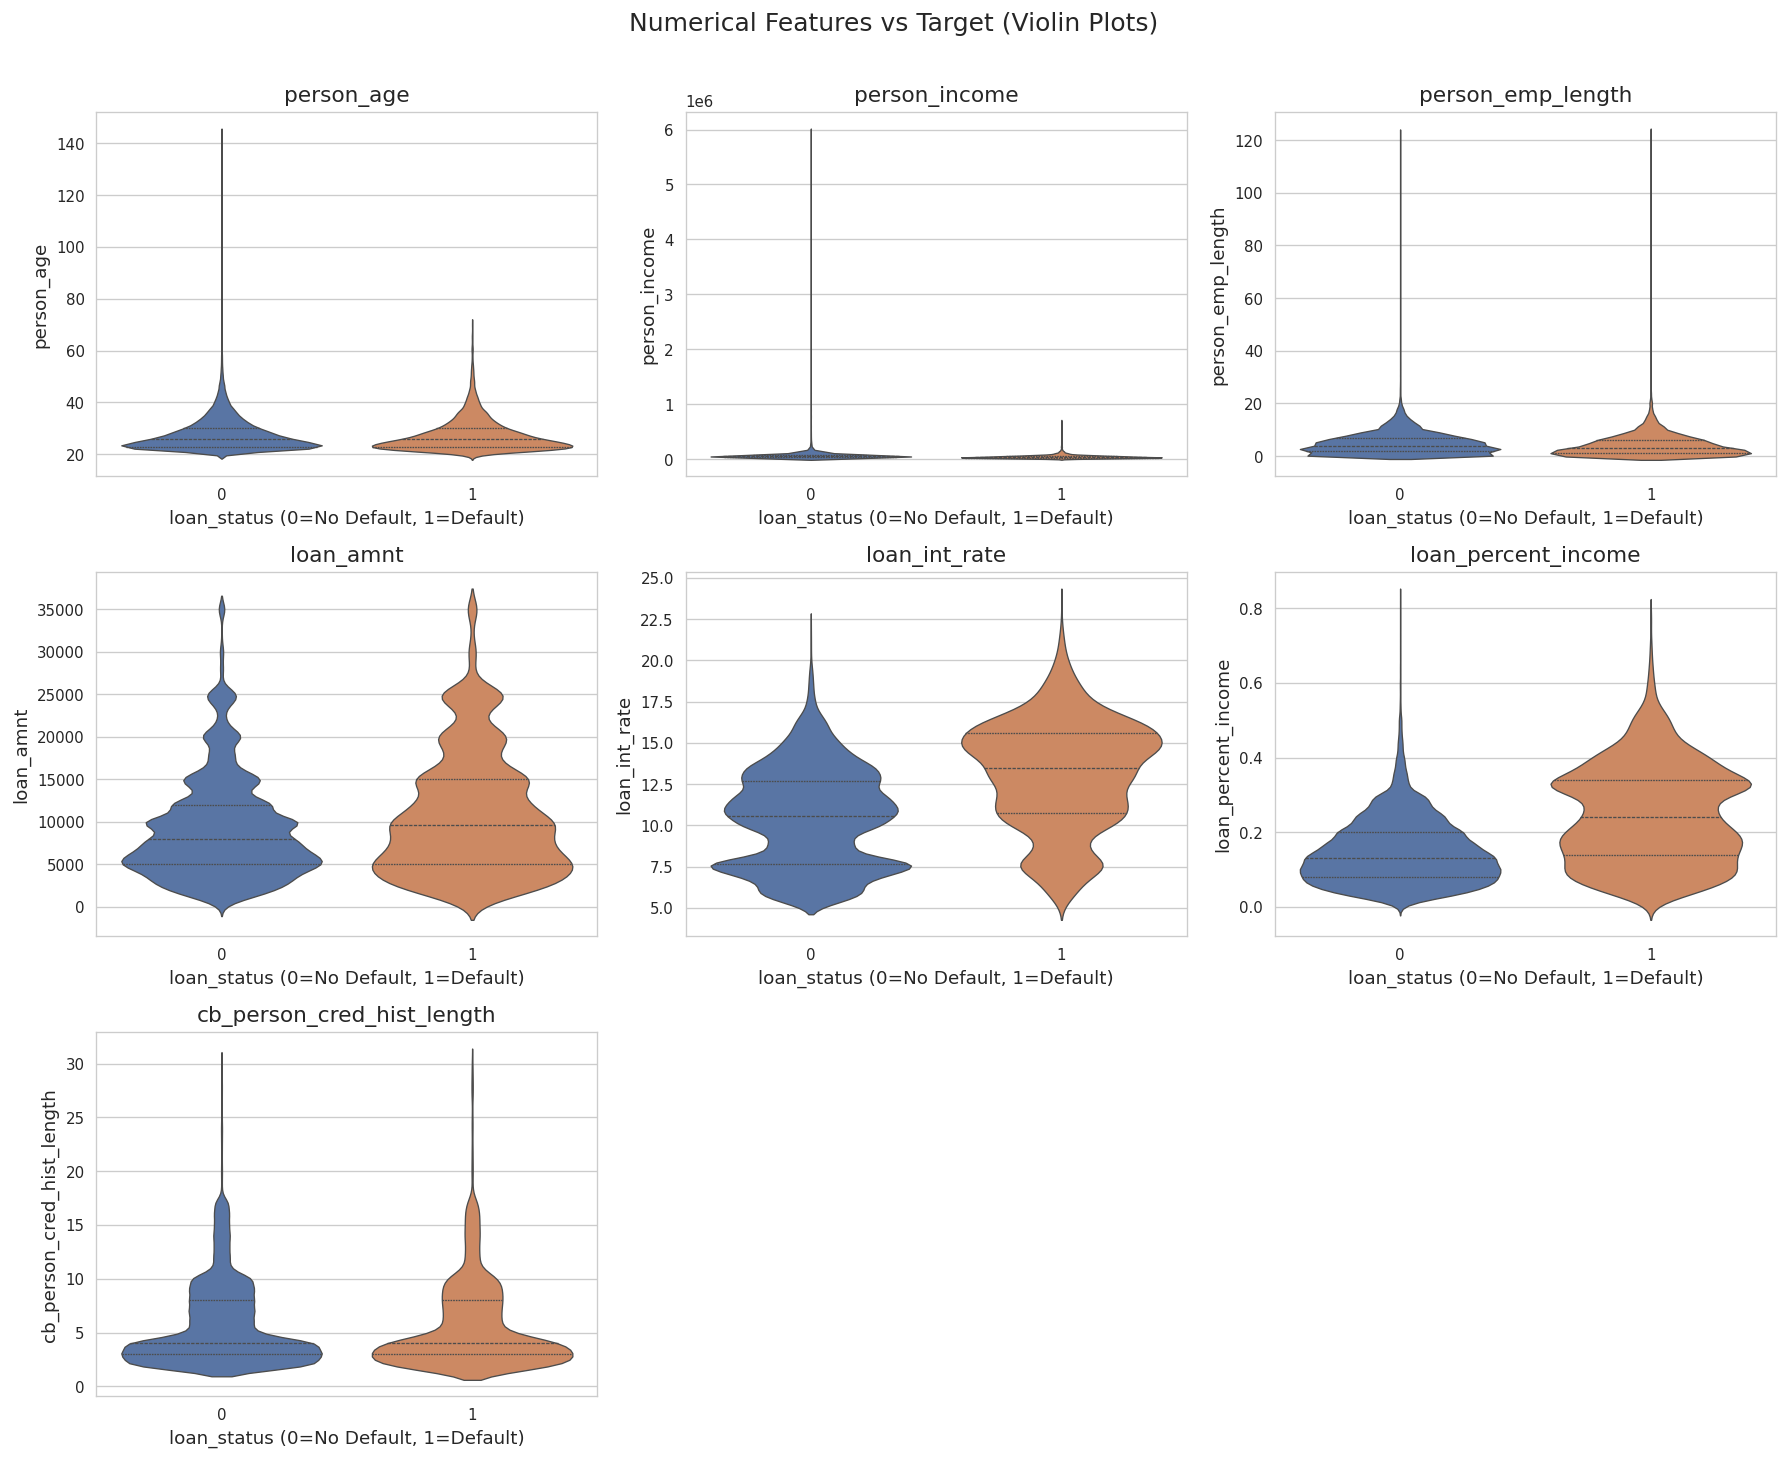

In [13]:
n_cols_bv = 3
n_rows_bv = int(np.ceil(len(NUMERICAL_COLS) / n_cols_bv))

fig, axes = plt.subplots(n_rows_bv, n_cols_bv, figsize=(15, n_rows_bv * 4))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    sns.violinplot(
        data=df, x=TARGET_COL, y=col, ax=axes[i],
        palette=PALETTE, inner='quartile', linewidth=0.8
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('loan_status (0=No Default, 1=Default)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical Features vs Target (Violin Plots)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 6b. Categorical Features — Default Rate per Category

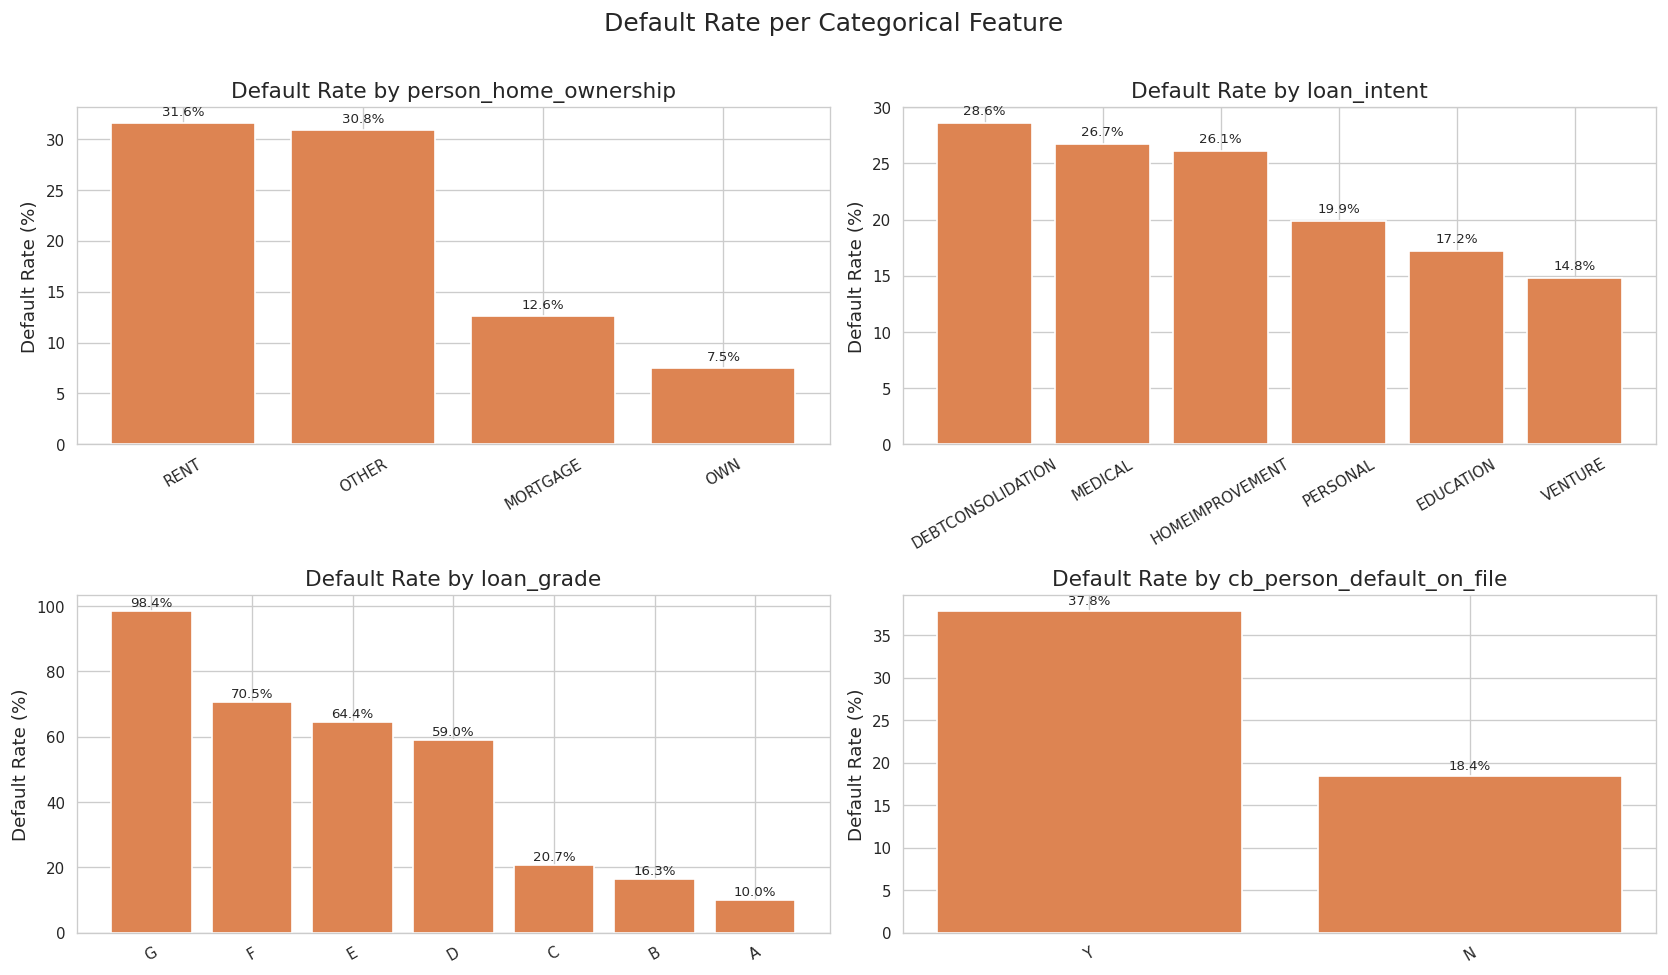

In [14]:
n_cols_cat = 2
n_rows_cat = int(np.ceil(len(CATEGORICAL_COLS) / n_cols_cat))

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(14, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    default_rate = (
        df.groupby(col)[TARGET_COL]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )
    bars = axes[i].bar(default_rate.index, default_rate.values,
                       color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Default Rate per Categorical Feature', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Key findings:**
- `loan_grade`: Very strong monotonic signal — Grade A has the lowest default rate, Grade G the highest. This will likely be among the top predictors.
- `cb_person_default_on_file`: Applicants with prior defaults have a substantially higher default rate — as expected.
- `loan_intent`: Some variation across categories, but weaker signal than grade.
- `person_home_ownership`: RENT and OTHER show slightly higher default rates than MORTGAGE/OWN.

## 7. Correlation Analysis

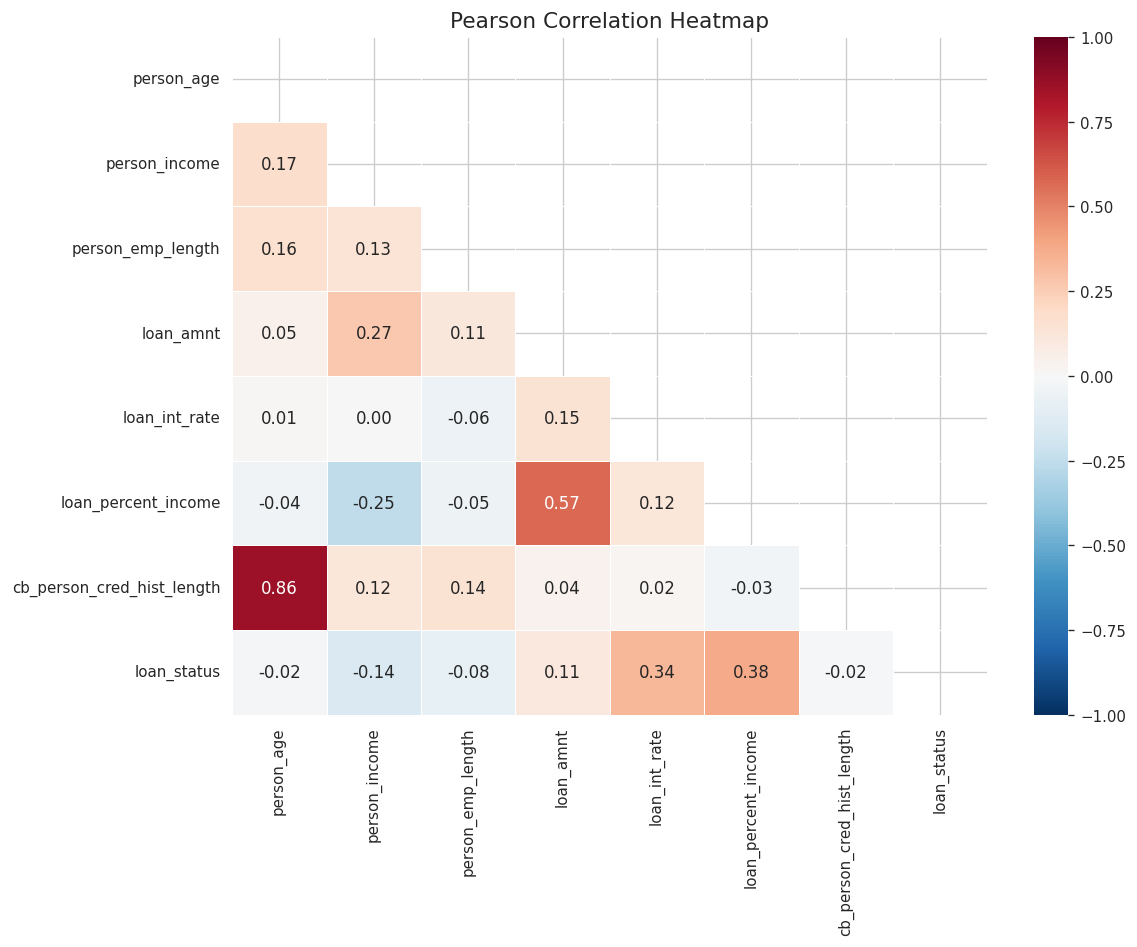

In [15]:
corr_cols = NUMERICAL_COLS + [TARGET_COL]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

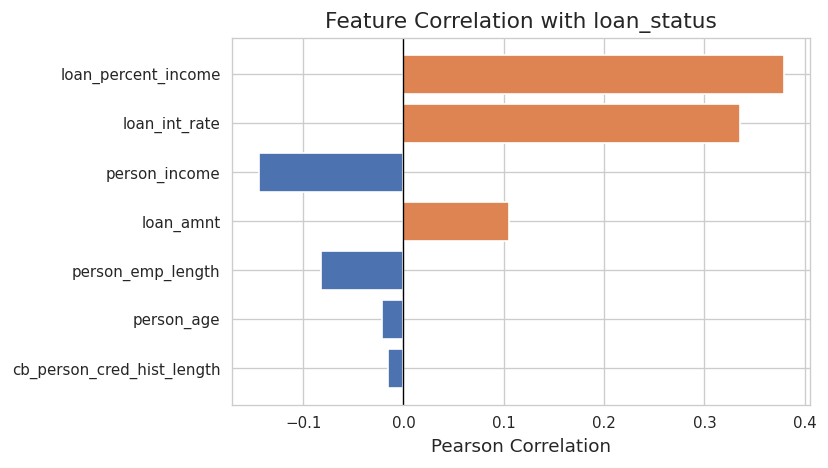

In [16]:
# Correlation with target specifically
target_corr = (
    corr_matrix[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with loan_status')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

**Findings:**
- `loan_int_rate` and `loan_percent_income` show the strongest positive correlation with default.
- `cb_person_cred_hist_length` shows a slight negative correlation (longer history → slightly lower default).
- `loan_int_rate` and `loan_amnt` may be correlated with `loan_grade` — check for multicollinearity in feature engineering.

## 8. EDA Summary & Conclusions

| Area | Finding | Action in Next Notebook |
|---|---|---|
| **Missing values** | `loan_int_rate`, `person_emp_length` have NaNs | Median imputation (group-wise for int_rate) |
| **Erroneous values** | `person_age > 100`, `person_emp_length > 60` | Drop these rows |
| **Class imbalance** | ~78% / 22% split | Use stratified split; evaluate with AUC/F1 |
| **Skewed distributions** | `person_income`, `loan_amnt` highly skewed | Consider log transform for LR |
| **Strong predictors** | `loan_grade`, `loan_int_rate`, `loan_percent_income`, `cb_person_default_on_file` | Prioritise in feature importance |
| **Multicollinearity** | `loan_int_rate` ↔ `loan_grade` likely correlated | Investigate VIF in feature engineering |
| **Categorical signal** | `loan_grade` has clean monotonic default rate | Ordinal encode, not one-hot |

**Next step:** `02_data_preprocessing.ipynb` — clean, encode, scale, and split the data.